<a href="https://colab.research.google.com/github/Marina4ij/FinalProject/blob/main/FinalProject14072026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Wikipedia Web Traffic (Kaggle)
Ежедневное количество просмотров статей Википедии за 2018-2019 годы.

In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn statsmodels

pmdarima not installed - using fixed SARIMA parameters
Install with: pip install pmdarima
Колонки и характеристики:
- Всего страниц: 63856
- Дней наблюдений: 730
- Пропусков (NaN): 1350886 (2.90%)
- Пример колонок: ['Page', '2018010100', '2018010200', '2018010300', '2018010400']...

Первые 3 строки:
                                             Page  2018010100  2018010200  \
0  黒い霧事件_(日本プロ野球)_ja.wikipedia_desktop_all-agents       154.0       128.0   
1            笹川陽平_ja.wikipedia_desktop_all-agents        38.0        77.0   
2        バンジージャンプ_ja.wikipedia_desktop_all-agents        21.0        16.0   

   2018010300  2018010400  
0       160.0       208.0  
1        78.0        65.0  
2        19.0        26.0  

Проводим EDA...

Итоговый размер данных: 45263994 строк
Диапазон дат: 2018-01-01 00:00:00 — 2019-12-31 00:00:00

Топ-5 страниц по среднему трафику:
                                                            mean  \
Page                                                         

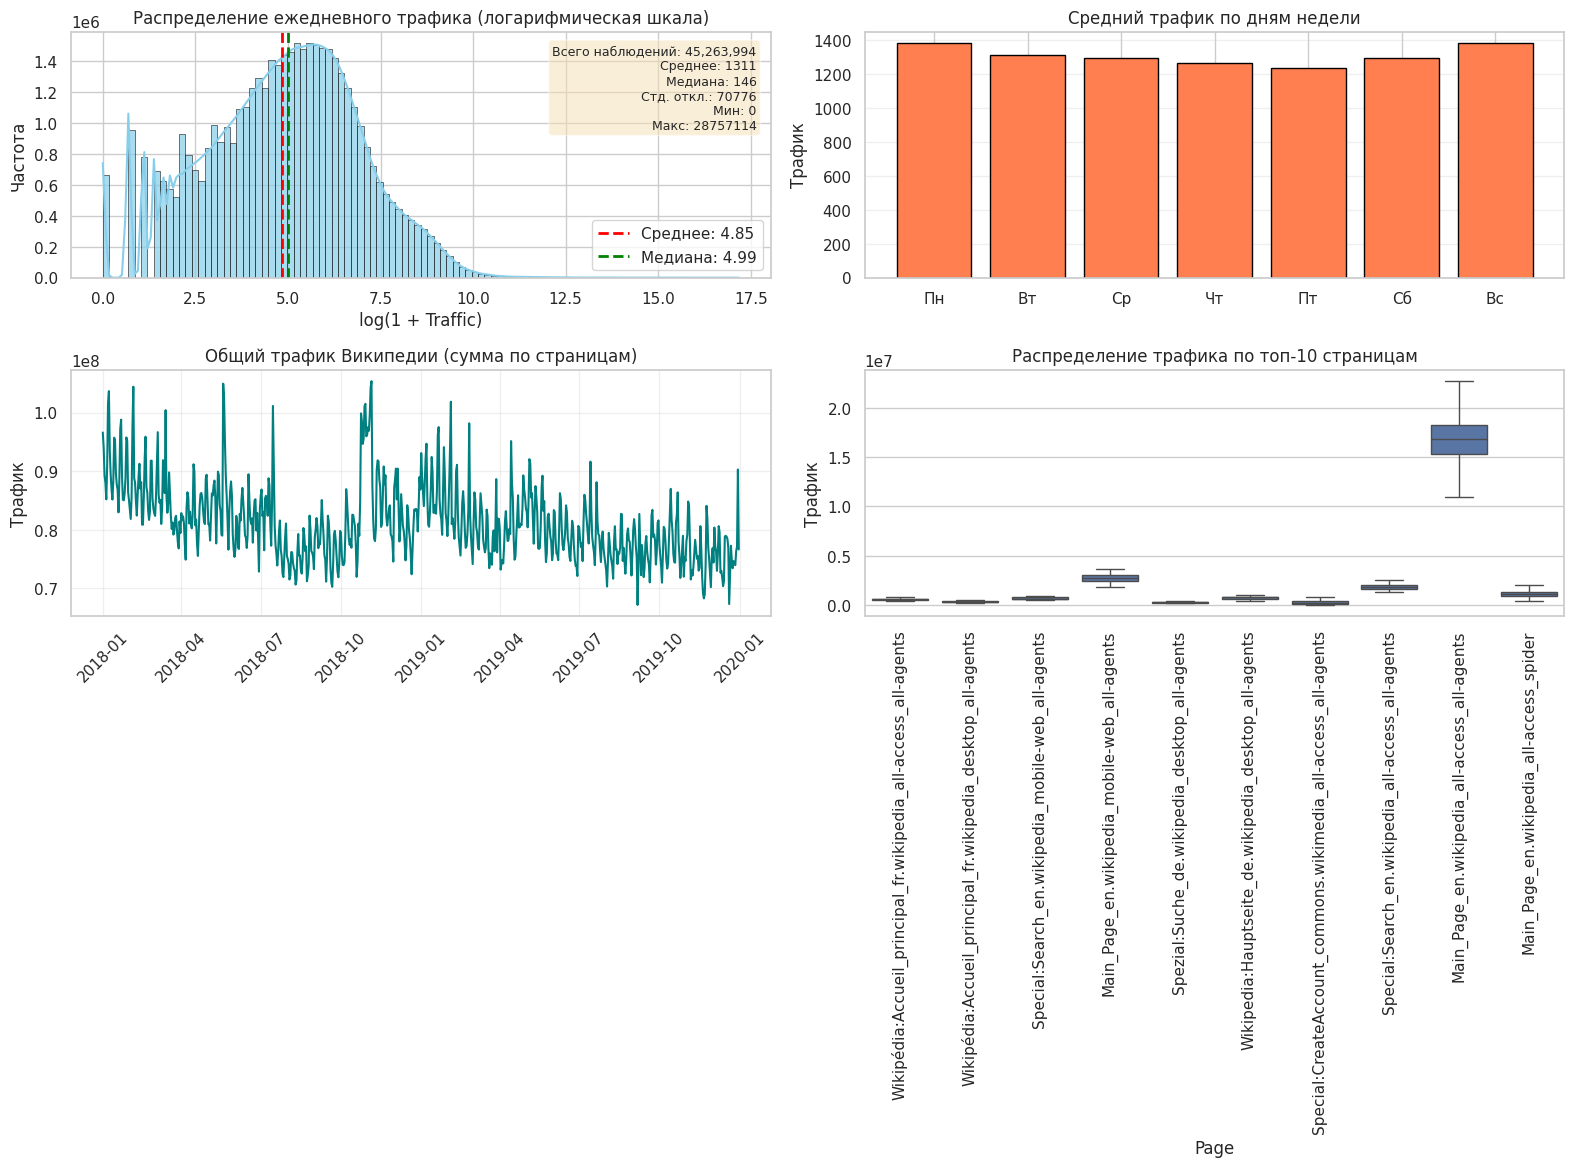


Предобработка данных...

Выбрана страница: Main_Page_en.wikipedia_all-access_all-agents

Размер данных после feature engineering: (700, 14)

Train: 595 obs, Test: 105 obs
Признаков: 13

Обучение 6 моделей...
[1/6] Linear Regression...
[2/6] Random Forest...
[3/6] SVR...
[4/6] ARIMA...
    ARIMA(5,1,1) - done
[5/6] SARIMA...
    Using fixed parameters: (2, 1, 2) x (1, 1, 1, 7)
    SARIMA - done
[6/6] Holt-Winters...
    Holt-Winters - done

Метрики моделей:
Linear Regression                   | RMSE: 1680437.6 | MAE: 1063713.8 | R²:  0.674
Random Forest                       | RMSE: 2086464.3 | MAE: 1373671.8 | R²:  0.498
SVR                                 | RMSE: 3476633.1 | MAE: 2759693.0 | R²: -0.395
ARIMA(5,1,1)                        | RMSE: 4023288.3 | MAE: 3279304.2 | R²: -0.868
SARIMA(2, 1, 2)x(1, 1, 1, 7)        | RMSE: 6020800.2 | MAE: 4836007.5 | R²: -3.183
Holt-Winters                        | RMSE: 3245094.1 | MAE: 2446169.4 | R²: -0.215

Лучшая модель: Linear Regression


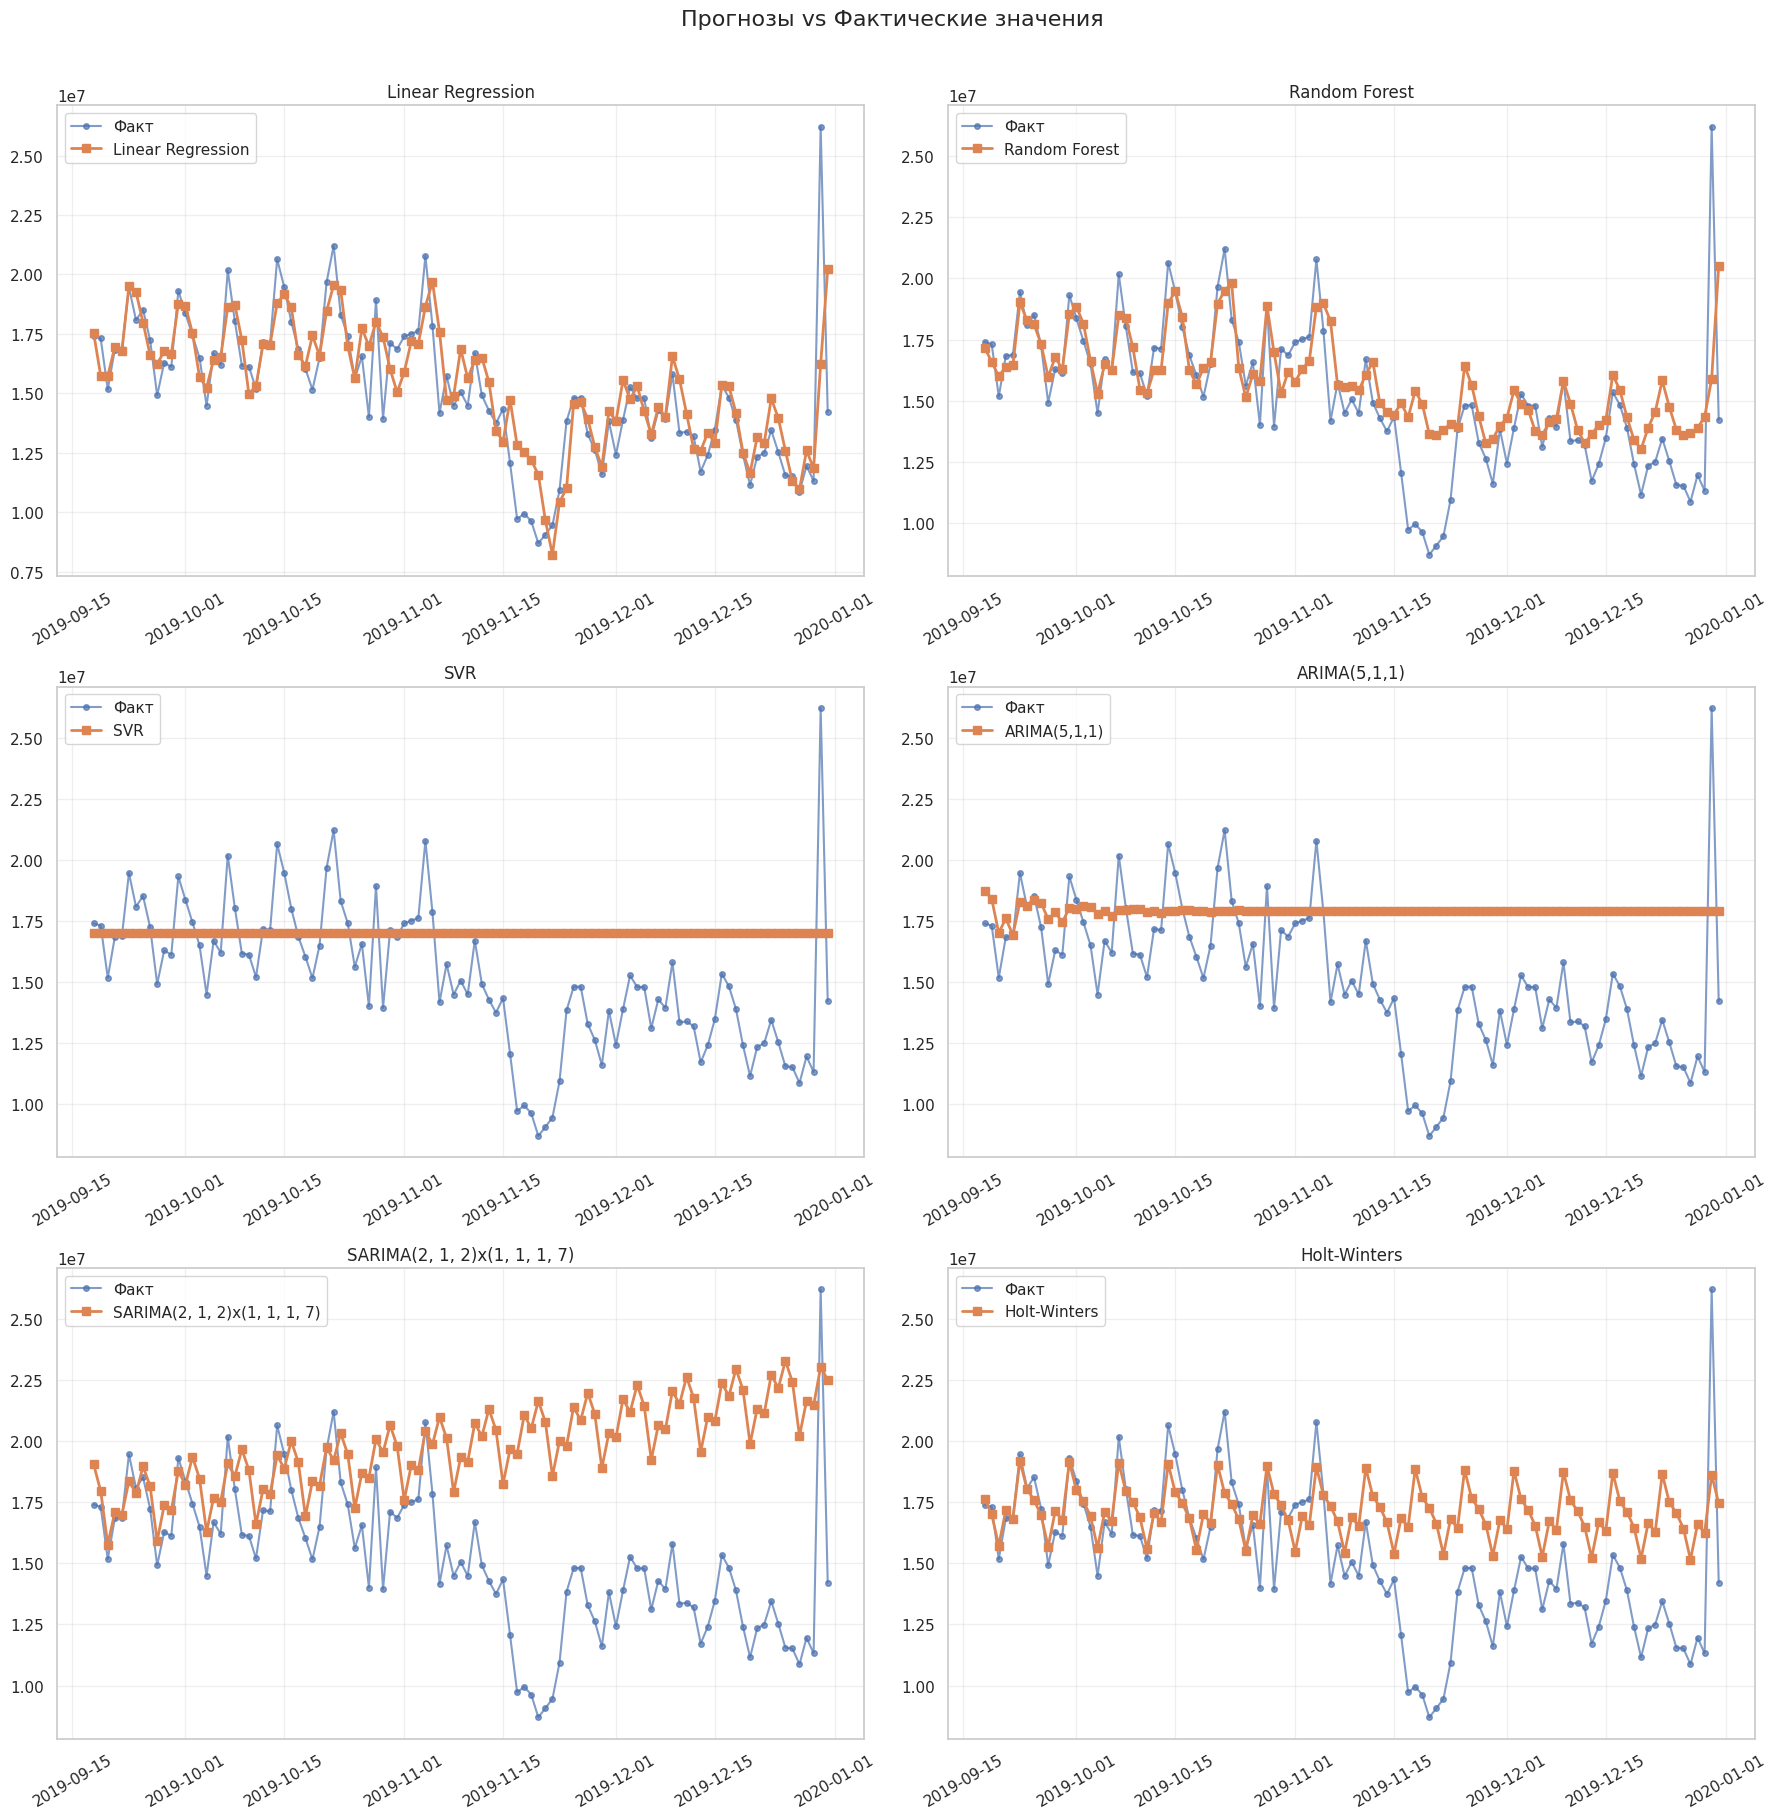

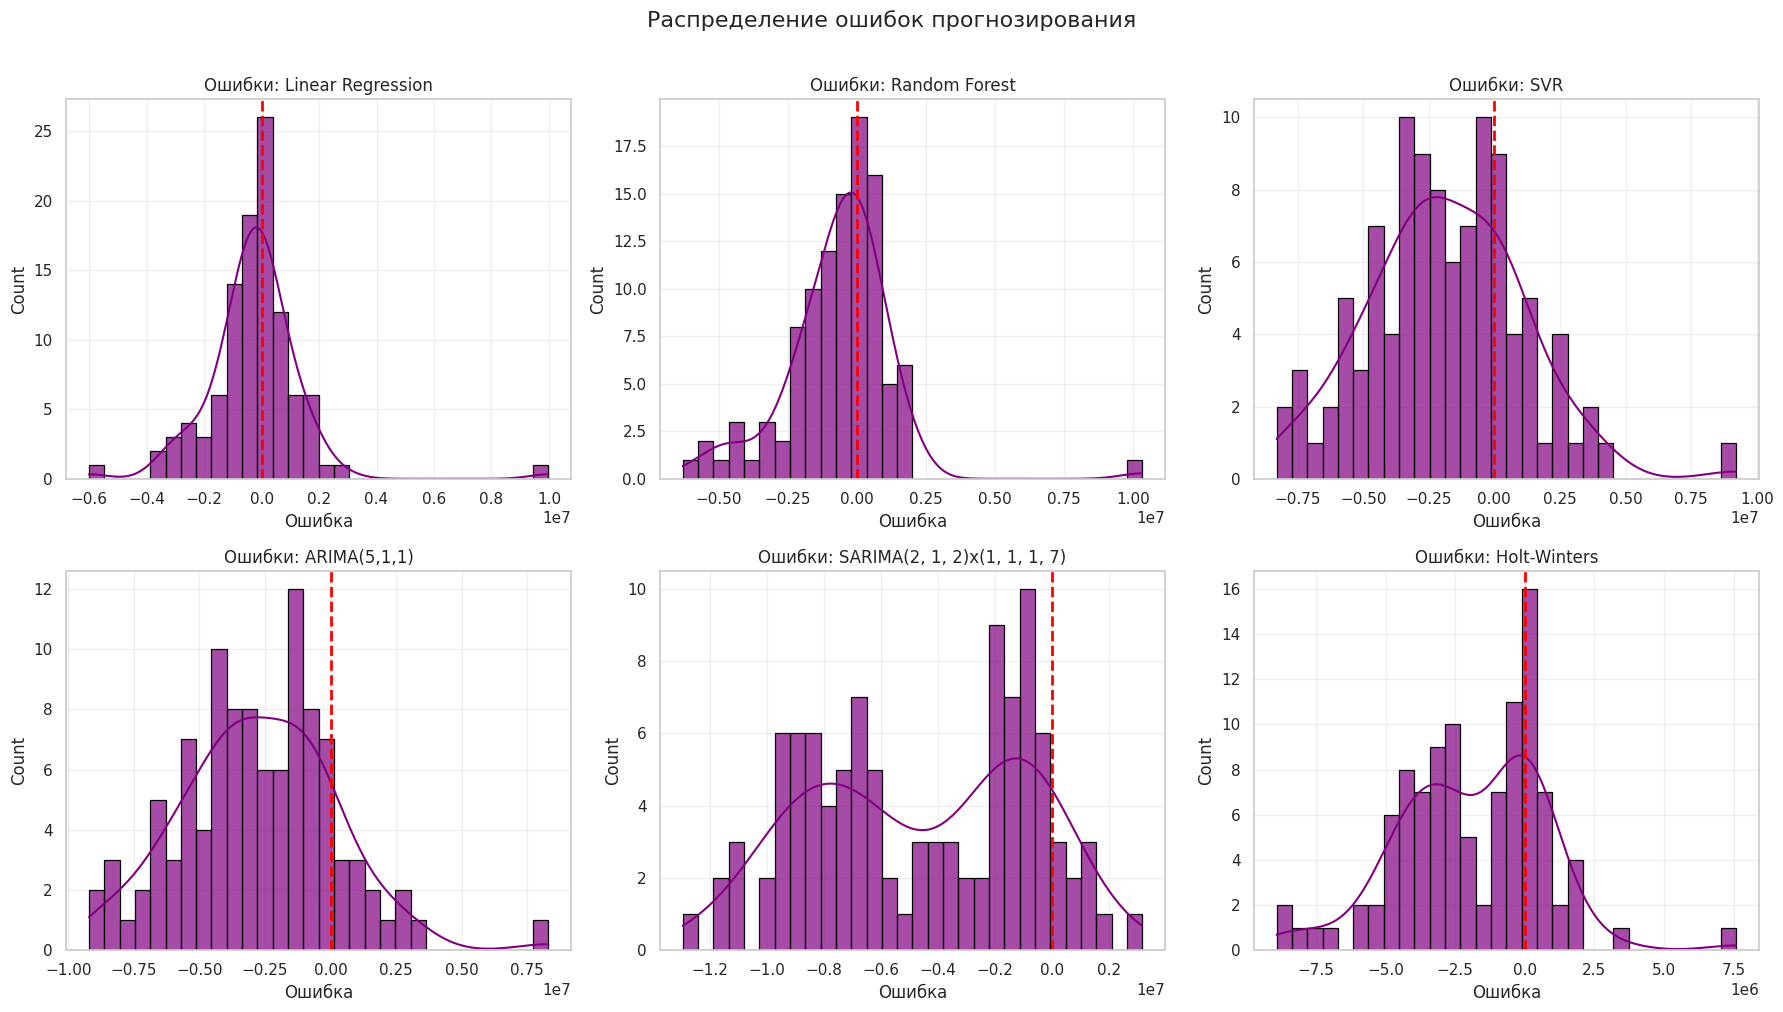

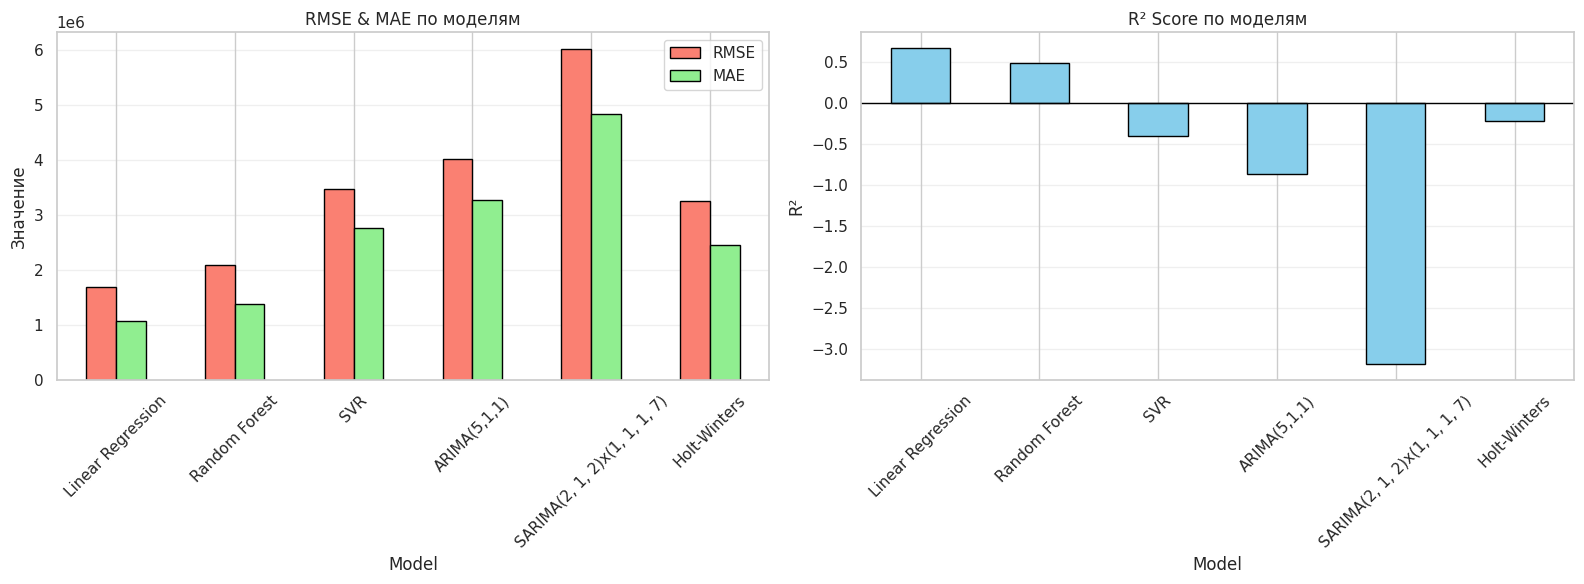

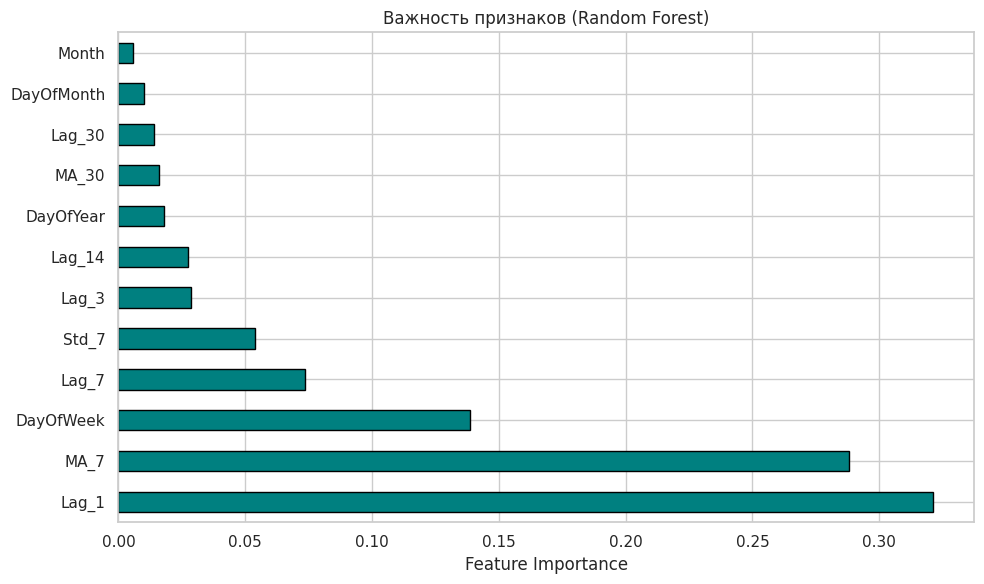

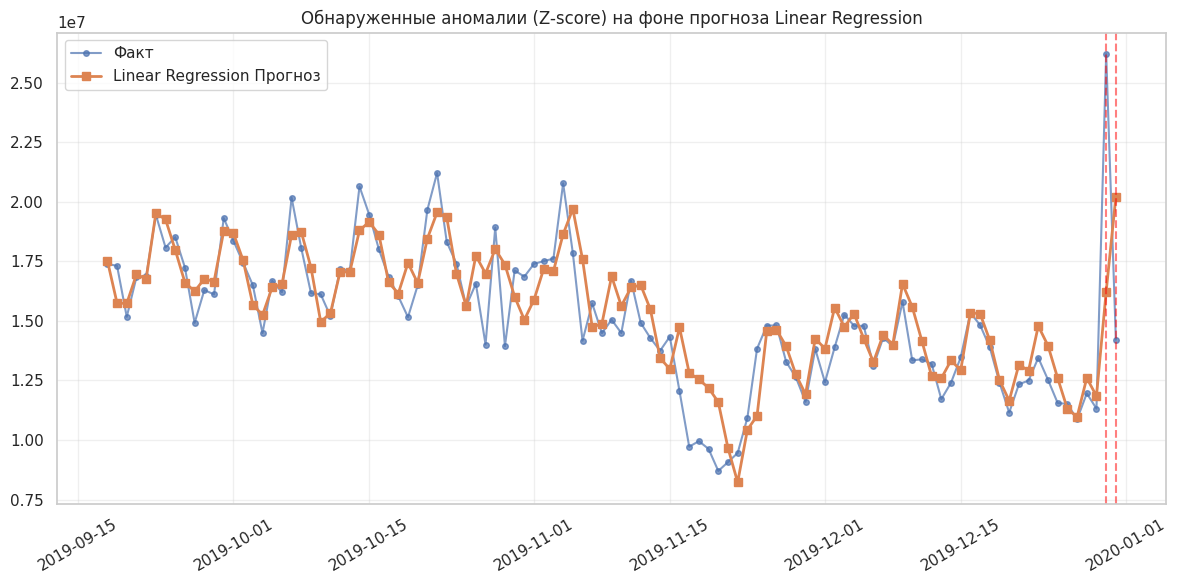

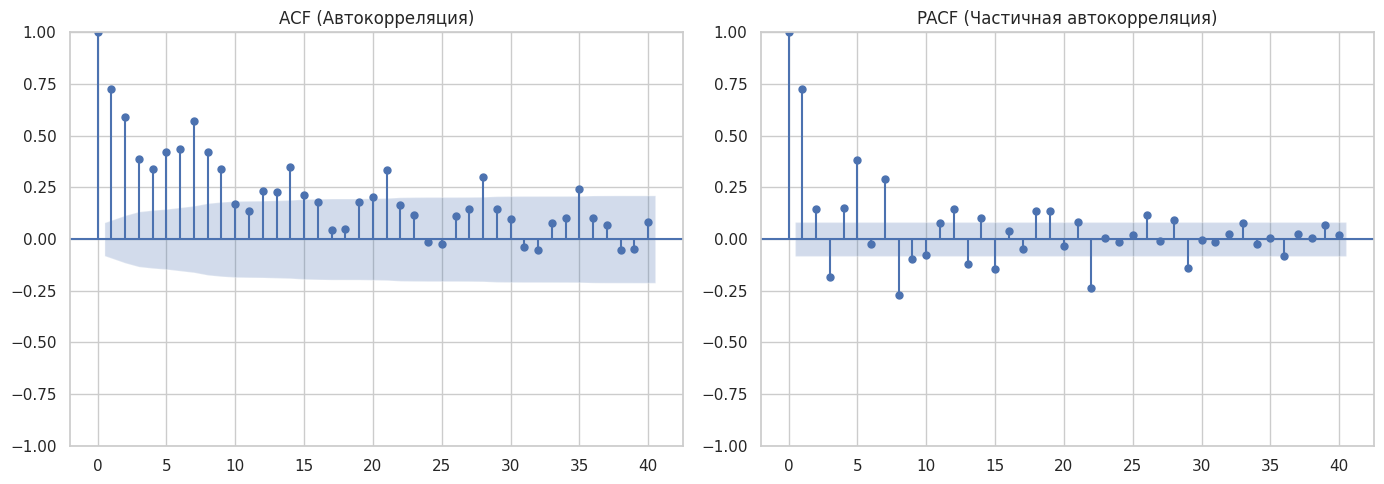


Все графики сохранены в директории.
Проект завершён успешно!


In [15]:
# -*- coding: utf-8 -*-
"""
Wikipedia Web Traffic Analysis
1. EDA
2. Preprocessing & Feature Engineering
3. Time Series Forecasting (6 ML/TS models: LR, RF, SVR, ARIMA, SARIMA, Holt-Winters)
4. Anomaly Detection
5. Visualizations (Forecasts, Errors, Metrics, Feature Importance)
"""

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.ensemble import IsolationForest

# Try to import pmdarima for auto_arima
try:
    from pmdarima import auto_arima
    PMDARIMA_AVAILABLE = True
    print("pmdarima available - using auto_arima for SARIMA")
except ImportError:
    PMDARIMA_AVAILABLE = False
    print("pmdarima not installed - using fixed SARIMA parameters")
    print("Install with: pip install pmdarima")

# Настройка стиля графиков
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12

# ==========================================
# 1. ЗАГРУЗКА ДАННЫХ (KAGGLE FORMAT)
# ==========================================
df = pd.read_csv("train/Wiki_Page_views.csv")

print("Колонки и характеристики:")
print(f"- Всего страниц: {len(df)}")
print(f"- Дней наблюдений: {len(df.columns) - 1}")
print(f"- Пропусков (NaN): {df.iloc[:, 1:].isna().sum().sum()} ({df.iloc[:, 1:].isna().sum().sum() / df.iloc[:, 1:].size * 100:.2f}%)")
print(f"- Пример колонок: {df.columns[:5].tolist()}...")
print("\nПервые 3 строки:")
print(df.head(3).iloc[:, :5])

# ==========================================
# 2. EDA (Исследовательский анализ)
# ==========================================
print("\nПроводим EDA...")

date_columns = [col for col in df.columns if col != "Page"]
df_long = df.melt(id_vars="Page", value_vars=date_columns, var_name="Date", value_name="Traffic")

# Преобразование дат
def parse_date_column(date_series):
    try:
        return pd.to_datetime(date_series)
    except:
        pass

    date_str = date_series.astype(str)
    sample = date_str.iloc[0]

    if len(sample) == 8 and sample.isdigit():
        return pd.to_datetime(date_str, format="%Y%m%d")
    elif len(sample) == 10 and sample.isdigit():
        return pd.to_datetime(date_str.str[:8], format="%Y%m%d")
    elif " " in sample:
        return pd.to_datetime(date_str.str[:10], format="%Y-%m-%d")
    elif "-" in sample and len(sample) == 10:
        return pd.to_datetime(date_str, format="%Y-%m-%d")
    else:
        return pd.to_datetime(date_str, infer_datetime_format=True, errors='coerce')

df_long["Date"] = parse_date_column(df_long["Date"])
df_long = df_long.dropna(subset=["Date", "Traffic"])

print(f"\nИтоговый размер данных: {len(df_long)} строк")
print(f"Диапазон дат: {df_long['Date'].min()} — {df_long['Date'].max()}")

# Статистика
stats = df_long.groupby("Page")["Traffic"].agg(["mean", "std", "min", "max"])
print("\nТоп-5 страниц по среднему трафику:")
print(stats.sort_values("mean", ascending=False).head())

# Визуализация EDA
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Распределение трафика (ИСПРАВЛЕНО: логарифмическая шкала + статистики)
# Используем логарифмическое преобразование для лучшего отображения распределения
traffic_log = np.log1p(df_long["Traffic"])  # log(1 + x) для обработки нулей

sns.histplot(traffic_log, bins=100, kde=True, ax=axes[0,0], color="skyblue", edgecolor='black', alpha=0.7)
axes[0,0].set_title("Распределение ежедневного трафика (логарифмическая шкала)")
axes[0,0].set_xlabel("log(1 + Traffic)")
axes[0,0].set_ylabel("Частота")

# Добавляем вертикальные линии для статистик
mean_log = traffic_log.mean()
median_log = traffic_log.median()
axes[0,0].axvline(mean_log, color='red', linestyle='--', linewidth=2, label=f'Среднее: {mean_log:.2f}')
axes[0,0].axvline(median_log, color='green', linestyle='--', linewidth=2, label=f'Медиана: {median_log:.2f}')
axes[0,0].legend()

# Добавляем текст со статистиками
stats_text = f"Всего наблюдений: {len(df_long):,}\n"
stats_text += f"Среднее: {df_long['Traffic'].mean():.0f}\n"
stats_text += f"Медиана: {df_long['Traffic'].median():.0f}\n"
stats_text += f"Стд. откл.: {df_long['Traffic'].std():.0f}\n"
stats_text += f"Мин: {df_long['Traffic'].min():.0f}\n"
stats_text += f"Макс: {df_long['Traffic'].max():.0f}"
axes[0,0].text(0.98, 0.95, stats_text, transform=axes[0,0].transAxes,
               verticalalignment='top', horizontalalignment='right',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
               fontsize=9)

# 2. Недельная сезонность
df_long["DayOfWeek"] = df_long["Date"].dt.dayofweek
weekly = df_long.groupby("DayOfWeek")["Traffic"].mean()
days = ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]
axes[0,1].bar(days, weekly, color="coral", edgecolor='black')
axes[0,1].set_title("Средний трафик по дням недели")
axes[0,1].set_ylabel("Трафик")
axes[0,1].grid(axis='y', alpha=0.3)

# 3. Динамика по времени
daily_agg = df_long.groupby("Date")["Traffic"].sum()
axes[1,0].plot(daily_agg.index, daily_agg.values, linewidth=1.5, color="teal")
axes[1,0].set_title("Общий трафик Википедии (сумма по страницам)")
axes[1,0].set_ylabel("Трафик")
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].grid(alpha=0.3)

# 4. Коробчатые диаграммы топ-10 страниц
top_pages = stats.sort_values("mean", ascending=False).index[:10]
df_top = df_long[df_long["Page"].isin(top_pages)]
sns.boxplot(data=df_top, x="Page", y="Traffic", ax=axes[1,1], showfliers=False)
axes[1,1].tick_params(axis='x', rotation=90)
axes[1,1].set_title("Распределение трафика по топ-10 страницам")
axes[1,1].set_ylabel("Трафик")

plt.tight_layout()
plt.savefig("1_eda_plots.png", dpi=150)
plt.show()

# ==========================================
# 3. ПРЕДОБРАБОТКА & FEATURE ENGINEERING
# ==========================================
print("\nПредобработка данных...")

df_long["Traffic"] = pd.to_numeric(df_long["Traffic"], errors="coerce")
df_long = df_long.dropna(subset=["Traffic"])

page_stats = df_long.groupby("Page")["Traffic"].mean()
target_page = page_stats.idxmax()
print(f"\nВыбрана страница: {target_page}")

ts_data = df_long[df_long["Page"] == target_page].copy()
ts_data = ts_data[["Date", "Traffic"]].copy()
ts_data.sort_values("Date", inplace=True)
ts_data.set_index("Date", inplace=True)

ts_data["Traffic"] = ts_data["Traffic"].interpolate(method="linear").bfill().ffill()

# Feature Engineering
ts_data["DayOfWeek"] = ts_data.index.dayofweek
ts_data["DayOfMonth"] = ts_data.index.day
ts_data["Month"] = ts_data.index.month
ts_data["DayOfYear"] = ts_data.index.dayofyear
ts_data["IsWeekend"] = (ts_data["DayOfWeek"] >= 5).astype(int)

for lag in [1, 3, 7, 14, 30]:
    ts_data[f"Lag_{lag}"] = ts_data["Traffic"].shift(lag)

ts_data["MA_7"] = ts_data["Traffic"].rolling(window=7).mean()
ts_data["MA_30"] = ts_data["Traffic"].rolling(window=30).mean()
ts_data["Std_7"] = ts_data["Traffic"].rolling(window=7).std()

ts_data.dropna(inplace=True)

print(f"\nРазмер данных после feature engineering: {ts_data.shape}")

split_idx = int(len(ts_data) * 0.85)
train = ts_data.iloc[:split_idx]
test = ts_data.iloc[split_idx:]

X_train = train.drop("Traffic", axis=1)
y_train = train["Traffic"]
X_test = test.drop("Traffic", axis=1)
y_test = test["Traffic"]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTrain: {X_train.shape[0]} obs, Test: {X_test.shape[0]} obs")
print(f"Признаков: {X_train.shape[1]}")

# ==========================================
# 4. 6 ПОДХОДОВ ML / ВРЕМЕННЫХ РЯДОВ
# ==========================================
print("\nОбучение 6 моделей...")

results = {}

# 1. Linear Regression
print("[1/6] Linear Regression...")
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
pred_lr = lr.predict(X_test_scaled)
results["Linear Regression"] = pred_lr

# 2. Random Forest
print("[2/6] Random Forest...")
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
results["Random Forest"] = pred_rf

# 3. SVR
print("[3/6] SVR...")
svr = SVR(kernel="rbf", C=1.0, epsilon=0.1)
svr.fit(X_train_scaled, y_train)
pred_svr = svr.predict(X_test_scaled)
results["SVR"] = pred_svr

# 4. ARIMA (классическая)
print("[4/6] ARIMA...")
try:
    arima_model = ARIMA(y_train, order=(7,1,1))
    arima_fit = arima_model.fit()
    pred_arima = arima_fit.forecast(steps=len(y_test))

    if len(pred_arima) < len(y_test):
        pred_arima = np.concatenate([pred_arima, np.full(len(y_test)-len(pred_arima), y_train.iloc[-1])])
    elif len(pred_arima) > len(y_test):
        pred_arima = pred_arima[:len(y_test)]

    results["ARIMA(5,1,1)"] = pred_arima
    print("    ARIMA(5,1,1) - done")
except Exception as e:
    print(f"    ARIMA failed: {e}, trying simpler model...")
    try:
        arima_model = ARIMA(y_train, order=(2,1,1))
        arima_fit = arima_model.fit()
        pred_arima = arima_fit.forecast(steps=len(y_test))
        results["ARIMA(2,1,1)"] = pred_arima
    except Exception as e2:
        print(f"    ARIMA(2,1,1) also failed: {e2}")
        results["ARIMA (naive)"] = np.full(len(y_test), y_train.mean())

# 5. SARIMA (сезонная ARIMA)
print("[5/6] SARIMA...")
try:
    if PMDARIMA_AVAILABLE:
        auto_model = auto_arima(
            y_train,
            seasonal=True,
            m=7,
            d=None,
            D=None,
            trace=False,
            error_action='ignore',
            suppress_warnings=True,
            stepwise=True,
            n_fits=20,
            random_state=42
        )

        best_order = auto_model.order
        best_seasonal = auto_model.seasonal_order
        sarima_name = f"SARIMA{best_order}x{best_seasonal}"
        print(f"    Best parameters: {best_order} x {best_seasonal}")

        pred_sarima = auto_model.predict(n_periods=len(y_test))
    else:
        sarima_model = SARIMAX(
            y_train,
            order=(2, 1, 2),
            seasonal_order=(1, 1, 1, 7),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        sarima_fit = sarima_model.fit(disp=False)
        pred_sarima = sarima_fit.forecast(steps=len(y_test))
        best_order = (2, 1, 2)
        best_seasonal = (1, 1, 1, 7)
        sarima_name = f"SARIMA{best_order}x{best_seasonal}"
        print(f"    Using fixed parameters: {best_order} x {best_seasonal}")

    if len(pred_sarima) < len(y_test):
        pred_sarima = np.concatenate([pred_sarima, np.full(len(y_test)-len(pred_sarima), y_train.iloc[-1])])
    elif len(pred_sarima) > len(y_test):
        pred_sarima = pred_sarima[:len(y_test)]

    results[sarima_name] = pred_sarima
    print(f"    SARIMA - done")

except Exception as e:
    print(f"    SARIMA failed: {e}")
    results["SARIMA (naive)"] = np.full(len(y_test), y_train.mean())

# 6. Holt-Winters
print("[6/6] Holt-Winters...")
try:
    hw_model = ExponentialSmoothing(y_train, trend="add", seasonal="add", seasonal_periods=7)
    hw_fit = hw_model.fit()
    pred_hw = hw_fit.forecast(steps=len(y_test))

    if len(pred_hw) < len(y_test):
        pred_hw = np.concatenate([pred_hw, np.full(len(y_test)-len(pred_hw), y_train.iloc[-1])])
    elif len(pred_hw) > len(y_test):
        pred_hw = pred_hw[:len(y_test)]

    results["Holt-Winters"] = pred_hw
    print("    Holt-Winters - done")
except Exception as e:
    print(f"    Holt-Winters failed: {e}")
    results["Holt-Winters (naive)"] = np.full(len(y_test), y_train.mean())

# ==========================================
# 5. ОЦЕНКА КАЧЕСТВА
# ==========================================
print("\nМетрики моделей:")
metrics = []
for name, preds in results.items():
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    metrics.append({"Model": name, "RMSE": rmse, "MAE": mae, "R²": r2})
    print(f"{name:35} | RMSE: {rmse:7.1f} | MAE: {mae:7.1f} | R²: {r2:6.3f}")

metrics_df = pd.DataFrame(metrics).set_index("Model")

best_model = metrics_df["RMSE"].idxmin()
print(f"\nЛучшая модель: {best_model}")

# ==========================================
# 6. ПОИСК АНОМАЛИЙ
# ==========================================
print("\nПоиск аномалий...")
residuals = y_test - results[best_model]

iso = IsolationForest(contamination=0.05, random_state=42)
iso_pred = iso.fit_predict(X_test)
anomalies_iso = X_test[iso_pred == -1]

z_scores = np.abs((residuals - residuals.mean()) / residuals.std())
anomalies_z = test.index[z_scores > 3]

Q1, Q3 = residuals.quantile(0.25), residuals.quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 3*IQR, Q3 + 3*IQR
anomalies_iqr = test.index[(residuals < lower) | (residuals > upper)]

print(f"Isolation Forest: {len(anomalies_iso)} аномалий")
print(f"Z-score (|Z|>3): {len(anomalies_z)} аномалий")
print(f"IQR метод: {len(anomalies_iqr)} аномалий")

# ==========================================
# ДОПОЛНИТЕЛЬНАЯ ДИАГНОСТИКА
# ==========================================
print("\n=== Дополнительная диагностика ===")

# 1. Проверка на переобучение
print("\n1. Проверка на переобучение (Train vs Test RMSE):")
for name, model_obj in [("Linear Regression", lr), ("Random Forest", rf), ("SVR", svr)]:
    if name == "Linear Regression":
        train_pred = model_obj.predict(X_train_scaled)
        test_pred = model_obj.predict(X_test_scaled)
    else:
        train_pred = model_obj.predict(X_train)
        test_pred = model_obj.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    print(f"{name:20} | Train RMSE: {train_rmse:7.1f} | Test RMSE: {test_rmse:7.1f} | Gap: {test_rmse - train_rmse:7.1f}")

# 2. Корреляция признаков с целевой переменной
print("\n2. Корреляция признаков с Traffic:")
correlations = X_train.corrwith(y_train).sort_values(ascending=False)
print(correlations)

# 3. Коэффициенты линейной регрессии
print("\n3. Коэффициенты Linear Regression:")
lr_coef = pd.Series(lr.coef_, index=X_train.columns).sort_values(ascending=False)
print(lr_coef)

# 4. Проверка прогнозов SARIMA/ARIMA
print("\n4. Статистика прогнозов:")
for name, preds in results.items():
    print(f"{name:35} | Mean: {preds.mean():7.1f} | Std: {preds.std():7.1f} | Min: {preds.min():7.1f} | Max: {preds.max():7.1f}")
print(f"{'Фактические значения':35} | Mean: {y_test.mean():7.1f} | Std: {y_test.std():7.1f} | Min: {y_test.min():7.1f} | Max: {y_test.max():7.1f}")

# ==========================================
# 7. ВИЗУАЛИЗАЦИЯ
# ==========================================
print("\nГенерация графиков...")

# 1. Прогнозы vs Факт (3x2 для 6 моделей)
fig, axes = plt.subplots(3, 2, figsize=(18, 18))
axes_flat = axes.flatten()

for i, (name, preds) in enumerate(results.items()):
    axes_flat[i].plot(y_test.index, y_test.values, "o-", label="Факт", markersize=4, alpha=0.7)
    axes_flat[i].plot(y_test.index, preds, "s-", label=name, linewidth=2)
    axes_flat[i].set_title(name)
    axes_flat[i].legend()
    axes_flat[i].tick_params(axis='x', rotation=30)
    axes_flat[i].grid(alpha=0.3)

plt.suptitle("Прогнозы vs Фактические значения", fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig("2_forecast_plots.png", dpi=150, bbox_inches='tight')
plt.show()

# 2. Ошибки прогнозирования (Residuals) - все 6 моделей
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()

for i, (name, preds) in enumerate(results.items()):
    err = y_test - preds
    sns.histplot(err, bins=30, kde=True, ax=axes_flat[i], color="purple", edgecolor='black', alpha=0.7)
    axes_flat[i].axvline(0, color="red", linestyle="--", linewidth=2)
    axes_flat[i].set_title(f"Ошибки: {name}")
    axes_flat[i].set_xlabel("Ошибка")
    axes_flat[i].grid(alpha=0.3)

plt.suptitle("Распределение ошибок прогнозирования", fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig("3_residuals_plots.png", dpi=150, bbox_inches='tight')
plt.show()

# 3. Сравнение метрик
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# RMSE и MAE
metrics_df[["RMSE", "MAE"]].plot(kind="bar", ax=ax[0], color=["salmon", "lightgreen"], edgecolor='black')
ax[0].set_title("RMSE & MAE по моделям")
ax[0].set_ylabel("Значение")
ax[0].tick_params(axis='x', rotation=45)
ax[0].legend()
ax[0].grid(axis='y', alpha=0.3)

# R²
metrics_df["R²"].plot(kind="bar", ax=ax[1], color="skyblue", edgecolor='black')
ax[1].set_title("R² Score по моделям")
ax[1].set_ylabel("R²")
ax[1].axhline(0, color="black", linewidth=1)
ax[1].tick_params(axis='x', rotation=45)
ax[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("4_metrics_comparison.png", dpi=150)
plt.show()

# 4. Важность признаков (Random Forest)
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
feat_imp.head(12).plot(kind="barh", color="teal", edgecolor='black')
plt.title("Важность признаков (Random Forest)")
plt.xlabel("Feature Importance")
plt.tight_layout()
plt.savefig("5_feature_importance.png", dpi=150)
plt.show()

# 5. Аномалии на графике
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.values, "o-", label="Факт", markersize=4, alpha=0.7)
plt.plot(y_test.index, results[best_model], "s-", label=f"{best_model} Прогноз", linewidth=2)
for date in anomalies_z:
    plt.axvline(date, color="red", linestyle="--", alpha=0.5)
plt.title(f"Обнаруженные аномалии (Z-score) на фоне прогноза {best_model}")
plt.legend()
plt.tick_params(axis='x', rotation=30)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("6_anomaly_detection.png", dpi=150)
plt.show()

# 6. ACF/PACF графики
try:
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    plot_acf(y_train, ax=axes[0], lags=40, title="ACF (Автокорреляция)")
    plot_pacf(y_train, ax=axes[1], lags=40, title="PACF (Частичная автокорреляция)")
    plt.tight_layout()
    plt.savefig("7_acf_pacf.png", dpi=150)
    plt.show()
except Exception as e:
    print(f"ACF/PACF visualization skipped: {e}")

print("\nВсе графики сохранены в директории.")
print("Проект завершён успешно!")